In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent  # Adjusts for notebook being in src/visualization/
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import time

import numpy as np
from matplotlib import pyplot as plt
from torch import Tensor
from torch.nn import functional as F

from src.common.env import G2OpGymEnv
from src.common.observation_space import (BusConnectivityGraphObsSpace)
from src.nri.utils import prior_from_env
from src.ra_agents.Encoder import Encoder
from src.ra_agents.graphormer.GraphormerEncoder import GraphormerNRIEncoder
from src.ra_agents.pretrain_encoder import create_dataset, GraphDataset
from src.ra_agents.pretrain_encoder import train
from src.visualization.utils import PlottingArgs, visualize_graph
from src.visualization.utils import get_node_styles
import seaborn as sns

sns.reset_orig()

/home/adrian/.conda/envs/L2RPN/lib/python3.10/site-packages/grid2op/MakeEnv/Make.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
def get_env():
    return G2OpGymEnv(
        obs_space_creation=lambda e: BusConnectivityGraphObsSpace(e.observation_space, normalization_boundaries={
            "active_power_forecast": [-122.4, 116.666],
            "active_power": [-122.4, 116.666],
            "reactive_power_forecast": [-85.7, 107.228],
            "reactive_power": [-85.7, 107.228],
            "voltage": [-142.1, 142.1],
            "voltage_angle": [-14.212, 1.246],
            "current": [0, 1512],
            "rho": [0, 1],
            "bus_indices": [0, 1],
            "substation_indices": [0, 1]
        }))


eps = 0.0000001
prior_for_graph_edges = 1.0
ds_size = 100

# create prior and dataset
env = get_env()
prior = prior_from_env(prior_for_graph_edges, env)
ds: GraphDataset = create_dataset(env, prior, ds_size)
ds_test: GraphDataset = create_dataset(get_env(), prior, ds_size // 10)

Create dataset: 100%|██████████| 10/10 [00:00<00:00, 13.63it/s]


In [3]:
graphormer_encoder = GraphormerNRIEncoder(x_dim=env.observation_space.x_dim, hidden_dim=16, num_layers=2, num_edge_types=2, max_degree=7, max_path_distance=9)
nri_encoder = Encoder(x_dim=env.observation_space.x_dim, hidden_dim=16, num_edge_types=2, dropout_prob=0.0, mark_powergrid_edges=False)

results = {
    "Graphormer": {"loss": [], "time": -1},
    "NRI":  {"loss": [], "time": -1},
}

encoders = {
    "Graphormer": graphormer_encoder,
    "NRI": nri_encoder
}

for name, encoder in encoders.items():
    start = time.time()
    results[name]["loss"] = train(
        encoder=encoder,
        ds=ds,
        testing_ds=ds_test,
        batch_size=1,
        evaluate_every_k_epochs=1,
        num_epochs=50,
        verbose=True
    )
    results[name]["time"] = (time.time() - start)


Epoch 49, Loss: 0.00006615, Max Grads: 0.00, , Evaluation loss: 0.00009083: 100%|██████████| 50/50 [01:45<00:00,  2.10s/it]
Epoch 49, Loss: 0.04146809, Max Grads: 0.01, , Evaluation loss: 0.07489892: 100%|██████████| 50/50 [02:22<00:00,  2.84s/it]


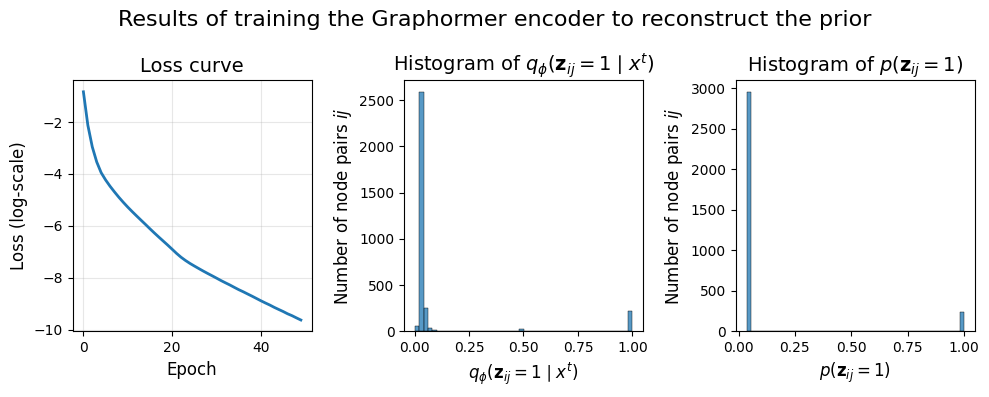

<Figure size 640x480 with 0 Axes>

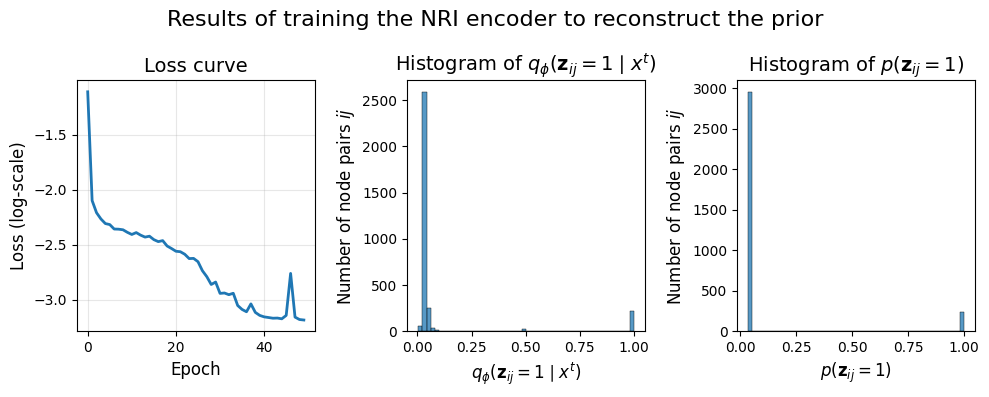

In [4]:
from torch.nn import Softmax

for name, encoder in encoders.items():
    fig, axs = plt.subplots(1, 3, figsize=(10, 4))
    fig.suptitle("Results of training the " + name + " encoder to reconstruct the prior", fontsize=16)
    train_losses = np.log(np.array([train_loss + eps for train_loss, _ in results[name]["loss"]]))
    axs[0].plot(train_losses, linewidth=2)
    axs[0].set_title("Loss curve", fontsize=14)
    axs[0].set_xlabel("Epoch", fontsize=12)
    axs[0].set_ylabel("Loss (log-scale)", fontsize=12)
    axs[0].grid(alpha=0.3)

    posterior = Softmax(-1)(nri_encoder.forward(x=ds[0].x))
    sns.histplot(posterior.detach().cpu().numpy()[:, 0], bins=50, ax=axs[1])
    axs[1].set_title(r"Histogram of $q_\phi(\mathbf{z}_{ij} = 1\mid x^t)$", fontsize=14)
    axs[1].set_xlabel(r"$q_\phi(\mathbf{z}_{ij} = 1\mid x^t)$", fontsize=12)
    axs[1].set_ylabel(r"Number of node pairs $ij$", fontsize=12)

    prior = ds[0].y
    sns.histplot(prior.detach().cpu().numpy()[:, 0], bins=50, ax=axs[2])
    axs[2].set_title(r"Histogram of $p(\mathbf{z}_{ij} = 1)$", fontsize=14)
    axs[2].set_xlabel(r"$p(\mathbf{z}_{ij} = 1)$", fontsize=12)
    axs[2].set_ylabel(r"Number of node pairs $ij$", fontsize=12)
    plt.tight_layout()
    plt.show()

    plt.savefig(Path(f"output/encoder/{name}_prior_training.png"))
    plt.savefig(Path(f"output/encoder/{name}_prior_training.svg"))

<Figure size 640x480 with 0 Axes>

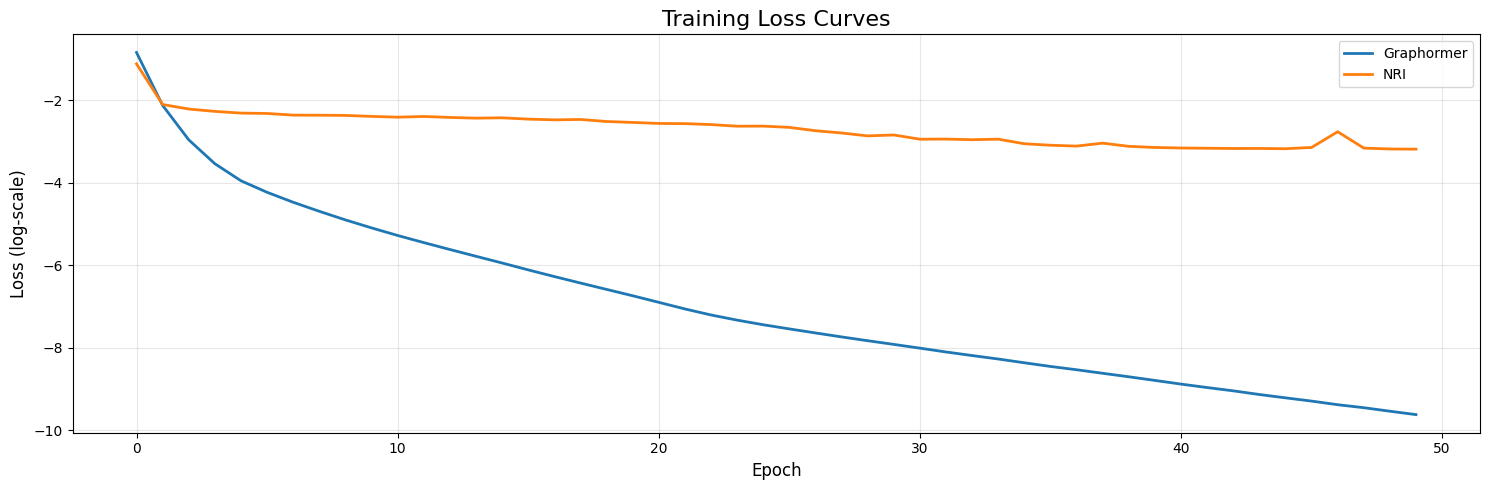

In [5]:
fig = plt.figure(figsize=(15, 5))
for name in results:
    plt.plot(np.log(np.array([train for train, _ in results[name]["loss"]]) + eps), label=name, linewidth=2)

plt.title("Training Loss Curves", fontsize=16)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss (log-scale)", fontsize=12)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(Path("output/encoder/comparison_training_loss.png"))
plt.savefig(Path("output/encoder/comparison_training_loss.svg"))
plt.show()

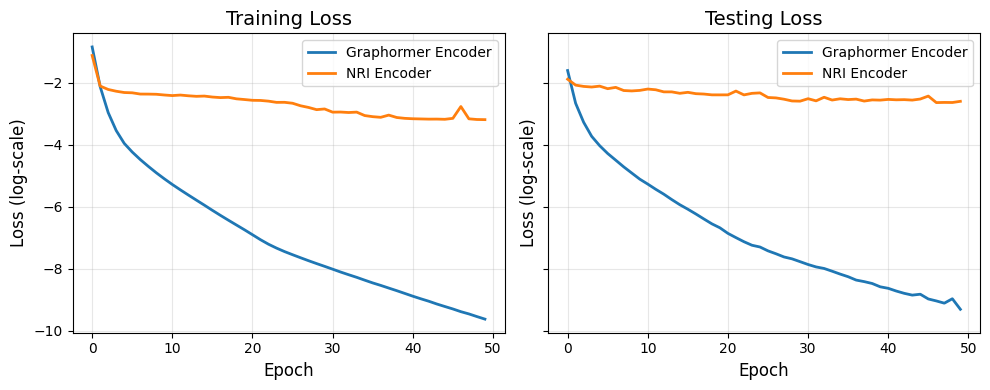

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

# ----- Loss Plot -----
graphormer_train_loss = np.log(np.array([train for train, _ in results["Graphormer"]["loss"]]) + eps)
nri_train_loss = np.log(np.array([train for train, _ in results["NRI"]["loss"]]) + eps)

axes[0].plot(graphormer_train_loss, label="Graphormer Encoder", linewidth=2)
axes[0].plot(nri_train_loss, label="NRI Encoder", linewidth=2)

axes[0].set_title("Training Loss", fontsize=14)
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Loss (log-scale)", fontsize=12)
axes[0].grid(alpha=0.3)
axes[0].legend()

# ----- Testing Loss Plot -----
graphormer_test_loss = np.log(np.array([test for _, test in results["Graphormer"]["loss"]], dtype=np.float32) + eps)
nri_test_loss = np.log(np.array([test for _, test in results["NRI"]["loss"]], dtype=np.float32) + eps)
x = np.arange(len(graphormer_test_loss))
graphormer_mask = ~np.isnan(graphormer_test_loss)
nri_mask = ~np.isnan(nri_test_loss)

axes[1].plot(x[graphormer_mask], graphormer_test_loss[graphormer_mask], label="Graphormer Encoder", linewidth=2)
axes[1].plot(x[nri_mask], nri_test_loss[nri_mask], label="NRI Encoder", linewidth=2)

axes[1].set_title("Testing Loss", fontsize=14)
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("Loss (log-scale)", fontsize=12)
axes[1].grid(alpha=0.3)
axes[1].legend()

# ----- Inference Time Bar Chart -----
#methods = ["Graphormer", "NRI"]
#values = [results["Graphormer"]["time"], results["NRI"]["time"]]

#bars = axes[2].bar(methods, values, color=["#4da6ff", "#ff9933"])

# Add exact value labels above bars
#for bar, val in zip(bars, values):
#    axes[2].annotate(f"{val:.2e}s",
#                     xy=(bar.get_x() + bar.get_width() / 2, val),
#                     xytext=(0, 6),
#                     textcoords="offset points",
#                     ha="center", va="bottom",
#                     fontsize=10)

#axes[2].set_title("Total Training Time", fontsize=14)
#axes[2].set_ylabel("Time (seconds)", fontsize=12)
#axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(Path("output/encoder/comparison_training_testing_loss.png"))
plt.savefig(Path("output/encoder/comparison_training_testing_loss.svg"))
plt.show()

Graphormer encoder is able to approximate the prior equally well as the NRI Encoder. Since it has a more general understanding of the structure of the powergrid, it is likely better suited to make predictions for latent graph structures. Additionally, inference in the GT module is ~x9 faster.

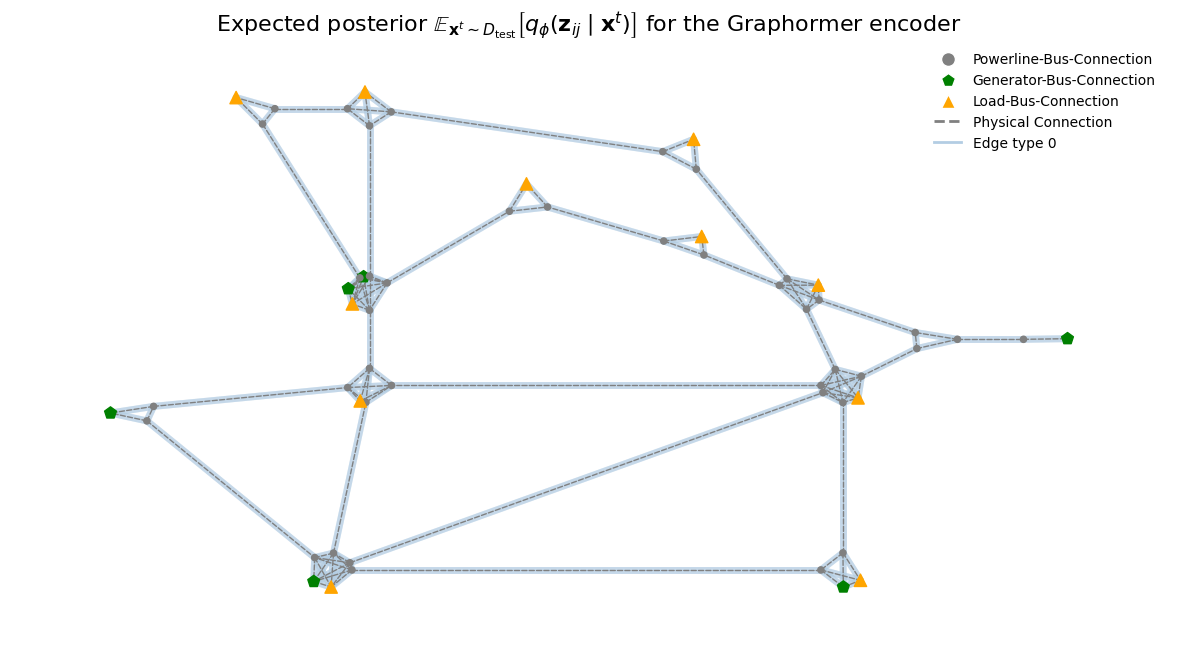

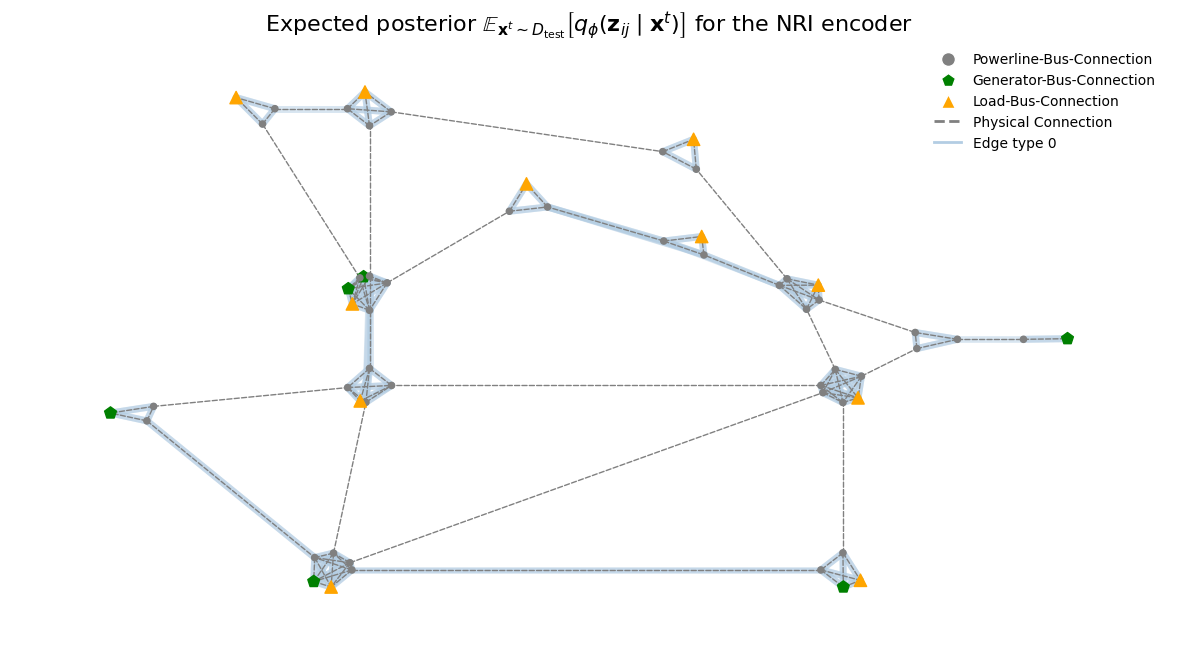

In [29]:
from torch_geometric.data import DataLoader

data_loader = DataLoader(ds_test, batch_size=1, shuffle=False)

for name, encoder in encoders.items():
    posteriors = []
    for data in data_loader:
        encoder_logits: Tensor = encoder.forward(x=data.x, powerline_edge_index=data.edge_index) # [B, E, K]
        p_z_given_x: Tensor = F.softmax(encoder_logits, dim=-1).detach().cpu().numpy() # [B, E, K]
        posteriors.append(p_z_given_x)

    mean_posterior = np.mean(posteriors, axis=0)  # [E, K]
    plotting_args = PlottingArgs(
        env.observation_space.num_nodes,
        get_node_styles(env._g2op_env, env.observation_space.__class__),
        powerline_edge_index=powerline_edge_index,
        latent_edge_probs=p_z_given_x,
    )
    visualize_graph(plotting_args)
    plt.title(r"Expected posterior $\mathbb{E}_{\mathbf{x}^t \sim D_\text{test}}\left[q_\phi(\mathbf{z}_{ij} \mid \mathbf{x}^t)\right]$ for the " + name + " encoder", fontsize=16)
    plt.tight_layout()
    plt.savefig(Path(f"output/encoder/{name}_posterior.png"))
    plt.savefig(Path(f"output/encoder/{name}_posterior.svg"))
    plt.show()


In [25]:
loss_curves_per_run = []
n_runs = 7
for i in range(n_runs):
    graphormer_encoder_short = GraphormerNRIEncoder(x_dim=env.observation_space.x_dim, hidden_dim=16, num_layers=2, num_edge_types=2, max_degree=7, max_path_distance=9)
    loss_curve = train(graphormer_encoder_short, ds, num_epochs=20)
    loss_curves_per_run.append([train for train, _ in loss_curve])

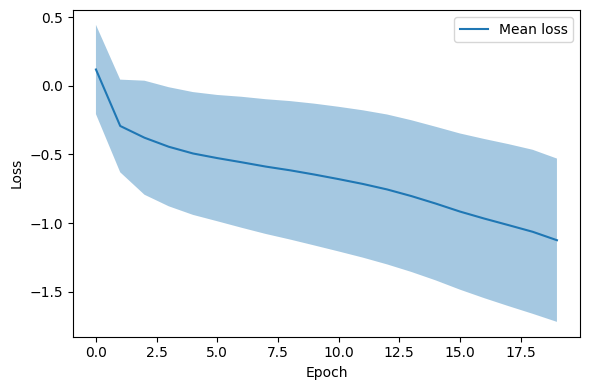

In [28]:
loss_arr = np.log(np.array(loss_curves_per_run) + eps)
mean_loss = loss_arr.mean(axis=0)
std_loss = loss_arr.std(axis=0)
epochs = np.arange(loss_arr.shape[1])

plt.figure(figsize=(6,4))
plt.plot(epochs, mean_loss, label="Mean loss")
plt.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, alpha=0.4)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()